In [1]:
pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: aastikmishra03
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images


100%|██████████| 1.68G/1.68G [00:17<00:00, 101MB/s]


In [3]:
import os

dataset_path = "./deepfake-and-real-images"
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
./deepfake-and-real-images/Dataset/Validation/Fake/fake_12274.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_11572.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_8297.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_4609.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_5964.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_283.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_7070.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_8790.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_3219.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_18996.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_14546.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_1093.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_5992.jpg
./deepfake-and-real-images/Dataset/Validation/Fake/fake_1807.jpg
./deepfake-and-real-images/Dataset/V

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

dataset_path = "./deepfake-and-real-images/Dataset"

In [5]:
image_size = (128, 128)
batch_size = 32
seed = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Train'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    seed=seed)


validation_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Train'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    seed=seed)




Found 112002 images belonging to 2 classes.
Found 28000 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D # Import Conv2D and MaxPooling2D

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


model = Sequential([
    Conv2D(32,kernel_size=(3, 3), activation='relu',padding='valid',input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),
    Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),
    Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),
    Conv2D(256,kernel_size=(3,3),padding='valid',activation='relu'),
    MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.0003),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.0003),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,782,529 (10.61 MB)

 Trainable params: 2,781,761 (10.61 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:









history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,

)

Epoch 1/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 620s 177ms/step - accuracy: 0.8736 - loss: 0.3507 - val_accuracy: 0.8777 - val_loss: 0.3188
Epoch 2/5
   1/3500 ━━━━━━━━━━━━━━━━━━━━ 1:40 29ms/step - accuracy: 0.9062 - loss: 0.2822

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3500/3500 ━━━━━━━━━━━━━━━━━━━━ 116s 33ms/step - accuracy: 0.9062 - loss: 0.2822 - val_accuracy: 0.8683 - val_loss: 0.3333
Epoch 3/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 621s 177ms/step - accuracy: 0.9103 - loss: 0.2524 - val_accuracy: 0.8965 - val_loss: 0.2750
Epoch 4/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 115s 33ms/step - accuracy: 0.9688 - loss: 0.1707 - val_accuracy: 0.8792 - val_loss: 0.3102
Epoch 5/5
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 616s 176ms/step - accuracy: 0.9228 - loss: 0.2171 - val_accuracy: 0.9280 - val_loss: 0.2078


## Save the Model

In [18]:
model.save('deepfake_detector_model4.h5')

Found 39428 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1233/1233 ━━━━━━━━━━━━━━━━━━━━ 167s 135ms/step
              precision    recall  f1-score   support

           0     0.9213    0.9088    0.9150     19641
           1     0.9107    0.9229    0.9168     19787

    accuracy                         0.9159     39428
   macro avg     0.9160    0.9159    0.9159     39428
weighted avg     0.9160    0.9159    0.9159     39428



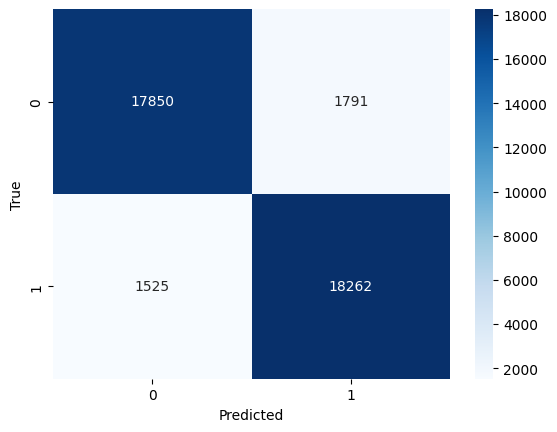

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


validation_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'Validation'),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


y_pred_probs = model.predict(validation_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


y_true = validation_generator.classes


print(classification_report(y_true, y_pred, digits=4))


cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Evaluate the model

In [9]:
loss, accuracy = model.evaluate(validation_generator)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

875/875 ━━━━━━━━━━━━━━━━━━━━ 117s 133ms/step - accuracy: 0.9282 - loss: 0.2082
Test Loss: 0.20802338421344757
Test Accuracy: 0.9283571243286133


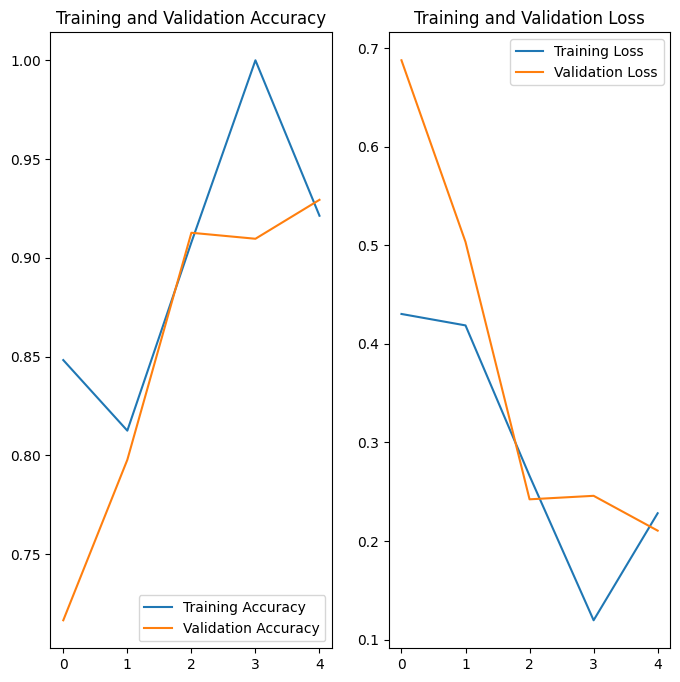

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(history.epoch)) # Use the actual number of epochs trained

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image


def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    return img_array


def predict_and_display(model, img_path, true_label, class_labels={0: 'Fake', 1: 'Real'}):
    img_array = load_and_preprocess_image(img_path)
    prediction = model.predict(img_array)
    predicted_class_index = (prediction > 0.5).astype(int)[0][0]
    predicted_label = class_labels[predicted_class_index]
    true_label_text = class_labels[true_label]

    plt.imshow(image.load_img(img_path))
    plt.title(f"Type: {true_label_text}, Predicted: {predicted_label}")
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


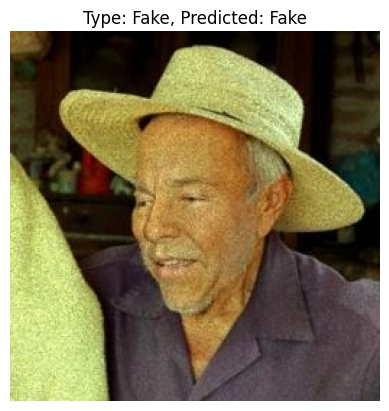

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


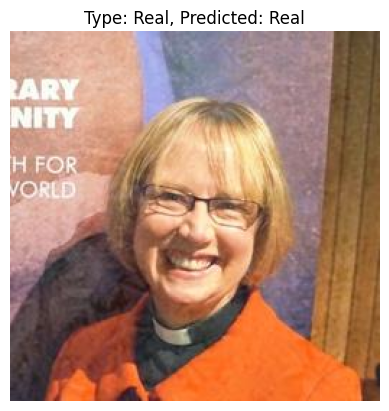

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


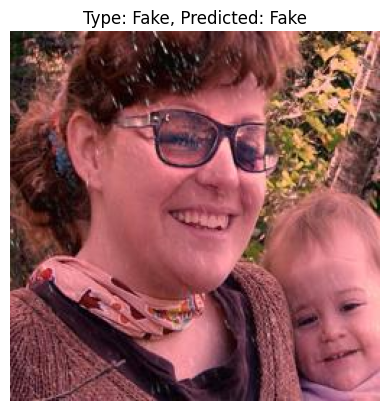

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


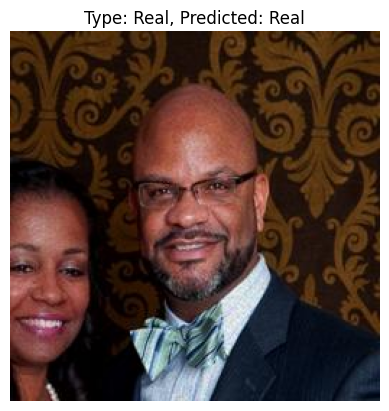

In [35]:
# Example usage:
# Replace with actual paths to your test images and their true labels
test_images_info = [
    {'path': './deepfake-and-real-images/Dataset/Test/Fake/fake_1.jpg', 'label': 0},
    {'path': './deepfake-and-real-images/Dataset/Test/Real/real_1.jpg', 'label': 1},
    {'path': './deepfake-and-real-images/Dataset/Test/Fake/fake_2.jpg', 'label': 0},
    {'path': './deepfake-and-real-images/Dataset/Test/Real/real_7.jpg', 'label': 1},
]

for img_info in test_images_info:
    predict_and_display(model, img_info['path'], img_info['label'])

In [29]:
model.save('deepfake_detector_model.h5')